Totalt antal bilder: 54
Rätt klassificerade: 33
Fel klassificerade: 18
Inga labels: 3
Träffsäkerhet (av alla bilder): 61.1%
Träffsäkerhet (top 3): 50.0%
Genomsnittlig högsta confidence vid rätt: 98.7%
Genomsnittlig högsta confidence vid fel: 93.3%

Topp 10 vanligaste predikterade label-termerna:
Electronics: 14
Accessories: 8
Jewelry: 7
Weapon: 6
Person: 6
Cutlery: 5
Clothing: 4
Blade: 4
Sport: 4
Porcelain: 4


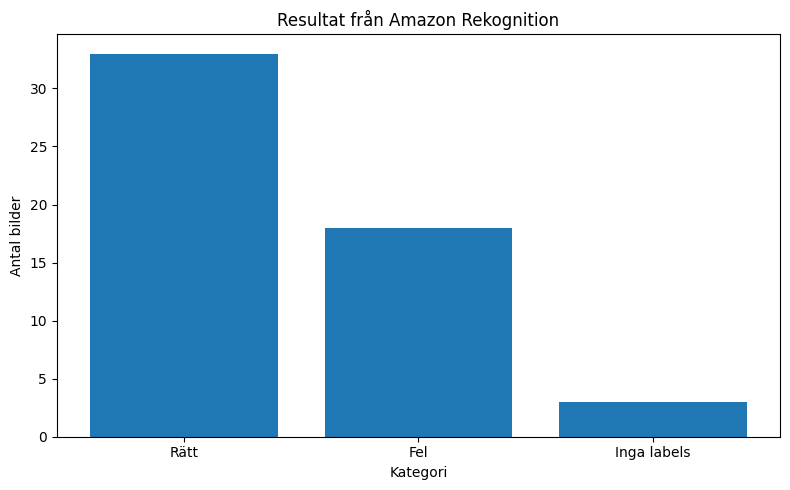

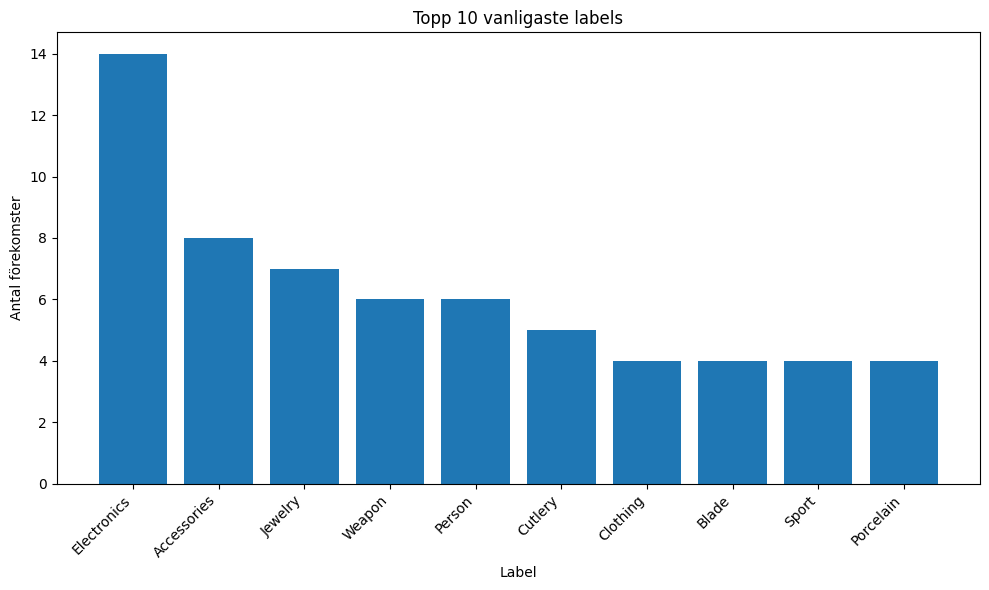

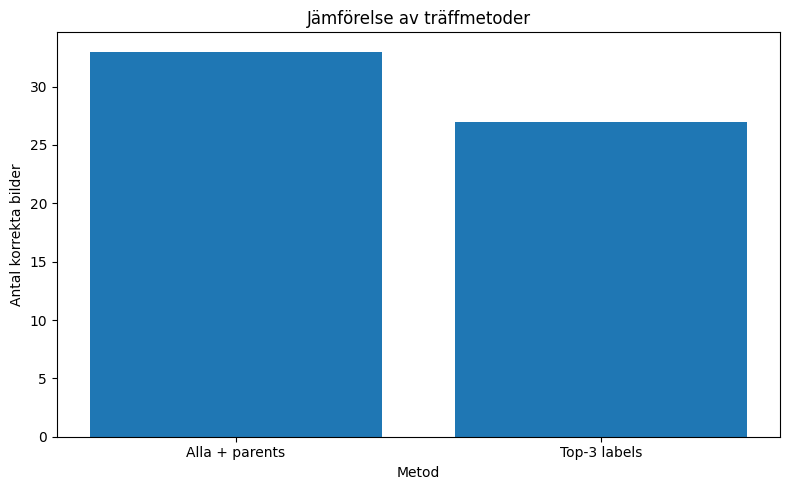

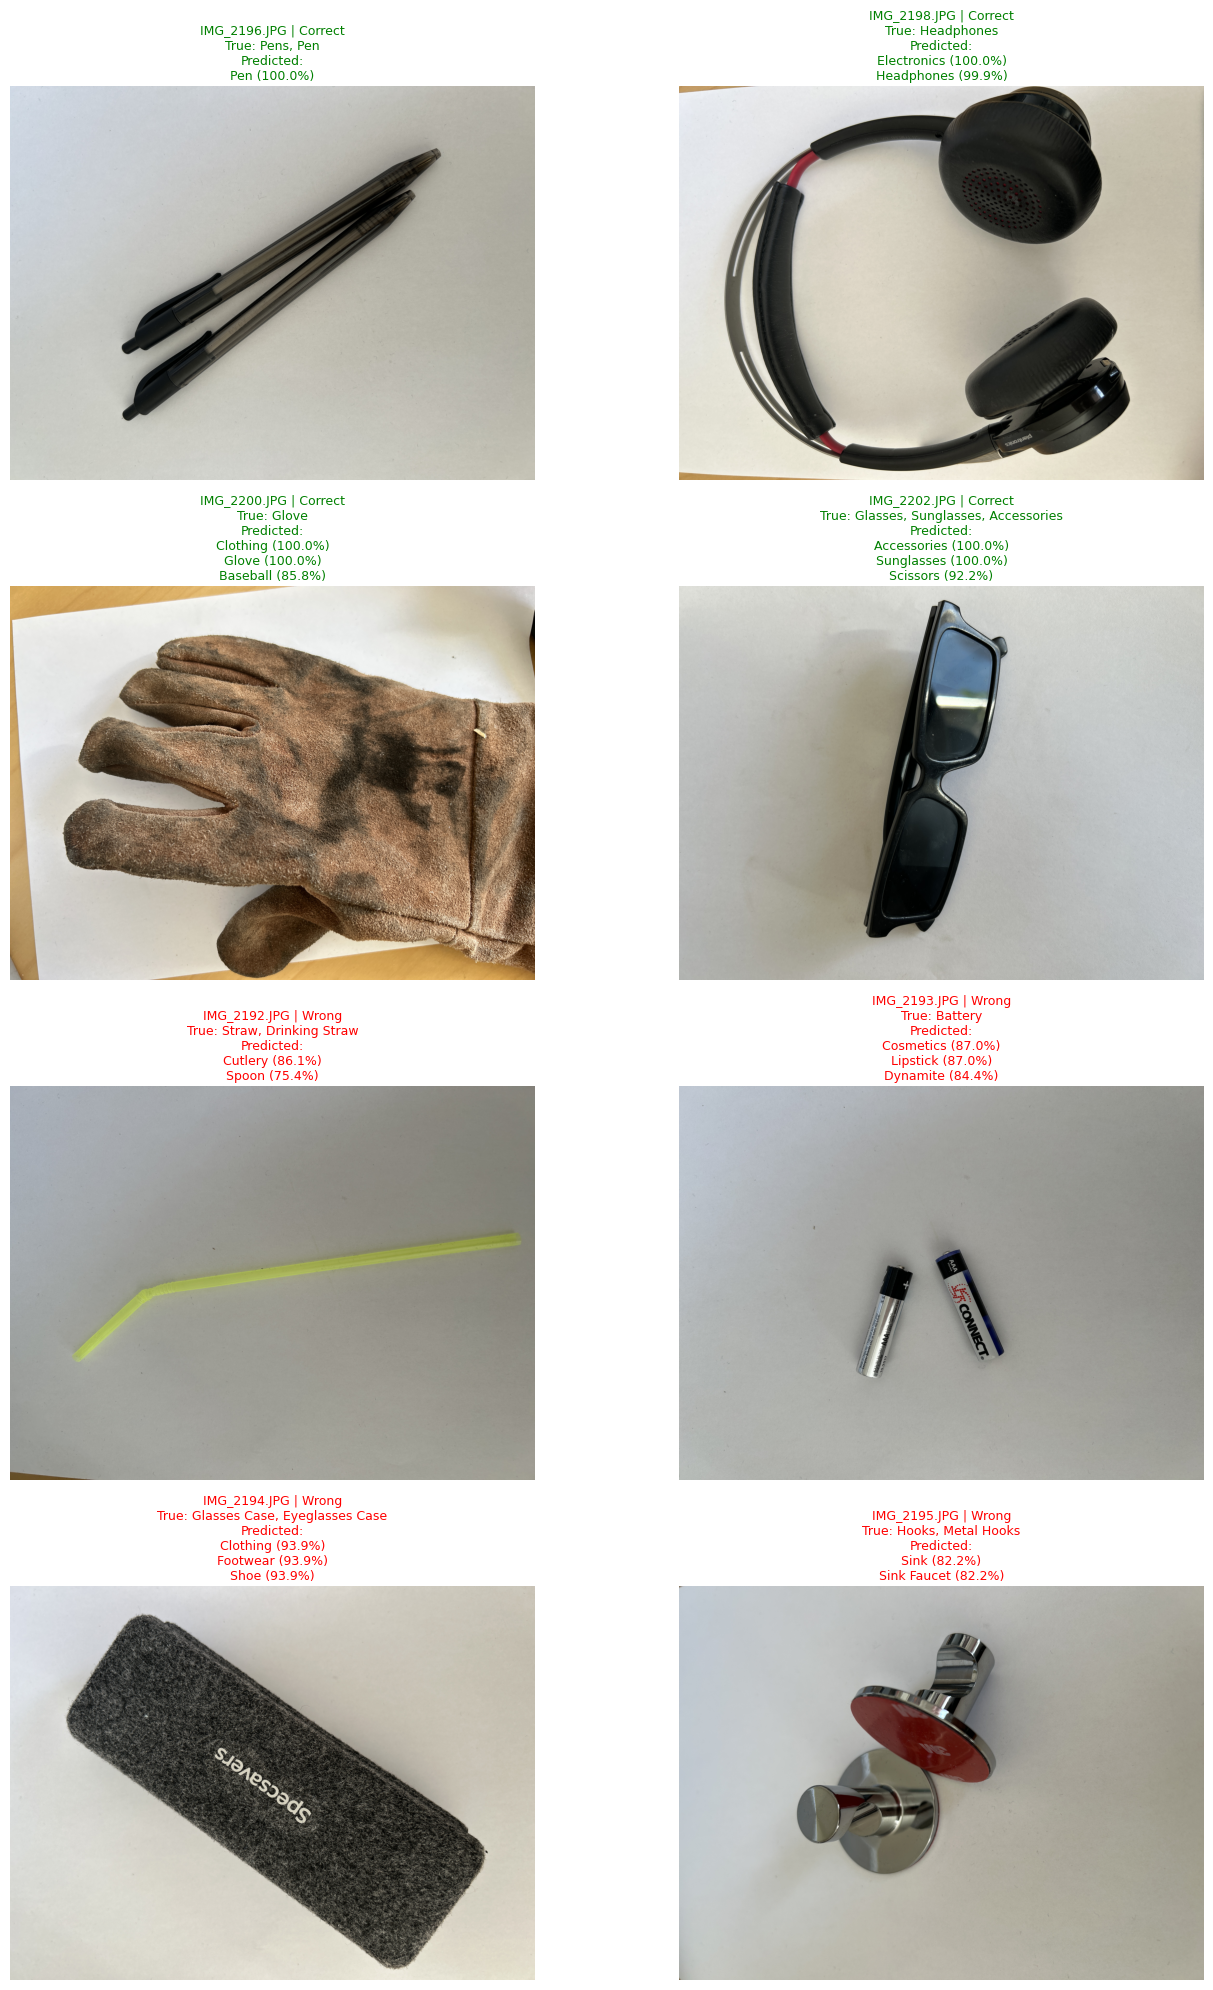

In [8]:
#################################################################################################
#   Nedan är analys av resultatet från Amazon Rekognition. Resultatet är sparat i en JSON-fil från AWS S3 som heter "rekognition_resultat.json".
#   Analysen inkluderar:
#   - Totalt antal bilder
#   - Antal rätt klassificerade bilder
#   - Antal fel klassificerade bilder
#   - Antal bilder utan labels
#   - Träffsäkerhet (accuracy) baserat på alla labels och även baserat på endast top-3 labels
#   - Genomsnittlig högsta confidence för rätt och fel klassificerade bilder
#   - Topp 10 vanligaste predikterade labels
#   - Exempel på detaljerade resultat för några bilder  
#################################################################################################

import json
from collections import Counter
import matplotlib.pyplot as plt
import os
import matplotlib.image as mpimg

# Funktion för att normalisera labels (ta bort mellanslag, göra små bokstäver, ersätta bindestreck och understreck)
def normalize_label(text):
    return text.strip().lower().replace("-", " ").replace("_", " ")

# Läser in JSON-fil från AWS Rekognition-resultatet
with open("rekognition_resultat.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Analysvariabler
correct_count = 0
wrong_count = 0
no_labels_count = 0
top3_correct_count = 0

label_counter = Counter()
detailed_results = []

confidences_correct = []
confidences_wrong = []

for item in data: 
    file_name = item["file_name"]
    true_labels = [normalize_label(label) for label in item["true_labels"]]
    predicted_labels = [label["Name"] for label in item["labels"]]

    label_counter.update(predicted_labels)

    predicted_terms = set()

    for label in item["labels"]:
        predicted_terms.add(normalize_label(label["Name"]))

        for parent in label.get("Parents", []):
            predicted_terms.add(normalize_label(parent))

    # Top 3 labels baserat på confidence
    top3_labels = [
        normalize_label(label["Name"])
        for label in sorted(item["labels"], key=lambda x: x["Confidence"], reverse=True)[:3]
    ]

    # Högsta confidence för bilden
    max_conf = max((label["Confidence"] for label in item["labels"]), default=None)


    if not item["labels"]:
        no_labels_count += 1
        match = False
        top3_match = False
        result_type = "No labels"

    else: 
        match = any(true_label in predicted_terms for true_label in true_labels)
        top3_match = any(true_label in top3_labels for true_label in true_labels)

        if match:
            correct_count += 1
            result_type = "Correct"
            if max_conf is not None:
                confidences_correct.append(max_conf)

        else:
            wrong_count += 1
            result_type = "Wrong"
            if max_conf is not None:
                confidences_wrong.append(max_conf)
        
        if top3_match:
            top3_correct_count += 1

    detailed_results.append({
        "file_name": file_name,
        "true_labels": item["true_labels"],
        "predicted_labels": predicted_labels,
        "top3_labels": top3_labels,
        "predicted_terms_with_parents": sorted(predicted_terms),
        "top3_match": top3_match,
        "max_confidence": max_conf,
        "result": result_type
    })



total_images = len(data)

print("Totalt antal bilder:", total_images)
print("Rätt klassificerade:", correct_count)
print("Fel klassificerade:", wrong_count)
print("Inga labels:", no_labels_count)

accuracy = correct_count / total_images * 100
top3_accuracy = top3_correct_count / total_images * 100

print(f"Träffsäkerhet (av alla bilder): {accuracy:.1f}%")
print(f"Träffsäkerhet (top 3): {top3_accuracy:.1f}%")

avg_conf_correct = sum(confidences_correct) / len(confidences_correct) if confidences_correct else 0
avg_conf_wrong = sum(confidences_wrong) / len(confidences_wrong) if confidences_wrong else 0

print(f"Genomsnittlig högsta confidence vid rätt: {avg_conf_correct:.1f}%")
print(f"Genomsnittlig högsta confidence vid fel: {avg_conf_wrong:.1f}%")

print("\nTopp 10 vanligaste predikterade label-termerna:")
for label, count in label_counter.most_common(10):
    print(f"{label}: {count}")

# print("\nExempel på detaljerade resultat:")
# for row in detailed_results[:10]:
#     print(row)
# 
# wrong_examples = [row for row in detailed_results if row["result"] == "Wrong"]
# 
# print("\nExempel på felklassificerade bilder:")
# for row in wrong_examples[:5]:
#     print(f"Fil: {row['file_name']}")
#     print(f"True labels: {row['true_labels']}")
#     print(f"Predicted labels: {row['predicted_labels']}")
#     print()

# -----------------------------
# Diagram 1: Rätt / Fel / Inga labels
# -----------------------------
categories = ["Rätt", "Fel", "Inga labels"]
values = [correct_count, wrong_count, no_labels_count]

plt.figure(figsize=(8, 5))
plt.bar(categories, values)
plt.title("Resultat från Amazon Rekognition")
plt.xlabel("Kategori")
plt.ylabel("Antal bilder")
plt.tight_layout()
plt.show()

# -----------------------------
# Diagram 2: Topp 10 vanligaste predikterade labels
# -----------------------------
top_10 = label_counter.most_common(10)

labels = [x[0] for x in top_10]
counts = [x[1] for x in top_10]

plt.figure(figsize=(10, 6))
plt.bar(labels, counts)
plt.xticks(rotation=45, ha="right")
plt.title("Topp 10 vanligaste labels")
plt.xlabel("Label")
plt.ylabel("Antal förekomster")
plt.tight_layout()
plt.show()

# -----------------------------
# Diagram 3: Vanlig träff vs top-3 träff
# -----------------------------
categories = ["Alla + parents", "Top-3 labels"]
values = [correct_count, top3_correct_count]

plt.figure(figsize=(8, 5))
plt.bar(categories, values)
plt.title("Jämförelse av träffmetoder")
plt.xlabel("Metod")
plt.ylabel("Antal korrekta bilder")
plt.tight_layout()
plt.show()


# -----------------------------
# Diagram 4: Visa 3 rätta och 3 felklassificerade bilder
# -----------------------------
correct_examples = [row for row in detailed_results if row["result"] == "Correct"][:4]
wrong_examples = [row for row in detailed_results if row["result"] == "Wrong"][:4]

example_rows = correct_examples + wrong_examples

cols = 2
rows = (len(example_rows) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = axes.flatten()

for ax in axes:
    ax.axis("off")

for ax, row in zip(axes, example_rows):
    image_path = os.path.join("Pictures", row["file_name"])

    if os.path.exists(image_path):
        img = mpimg.imread(image_path)
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, "Bild saknas", ha="center", va="center")

    ax.axis("off")

    # Hämta originalraden från data för confidence
    item = next((x for x in data if x["file_name"] == row["file_name"]), None)

    predicted_text = "Inga labels"
    if item and item["labels"]:
        top_preds = [
            f"{label['Name']} ({label['Confidence']:.1f}%)"
            for label in item["labels"][:3]
        ]
        predicted_text = "\n".join(top_preds)

    title = (
        f"{row['file_name']} | {row['result']}\n"
        f"True: {', '.join(row['true_labels'])}\n"
        f"Predicted:\n{predicted_text}"
    )

    title_color = "green" if row["result"] == "Correct" else "red"
    ax.set_title(title, fontsize=9, color=title_color, wrap=True)

plt.tight_layout()
plt.show()